#  A/B Test Analysis: Cookie Cats Mobile Game
### Optimization of First Gate Placement (Level 30 vs Level 40)

**Project Context:** Cookie Cats is a popular mobile puzzle game. This analysis examines the impact of moving the first 'gate' from level 30 to level 40 on player retention.

> **Hypothesis:** Moving the gate to level 40 will decrease retention because the longer stretch of gameplay without a forced break leads to player burnout.

### Key Metrics Summary
To evaluate the impact of the gate placement, we focus on the following Key Performance Indicators (KPIs):

| Metric | Description | Business Goal |
| :--- | :--- | :--- |
| **Retention 1d** | % of players returning 1 day after install | Measure initial "hook" and short-term engagement. |
| **Retention 7d** | % of players returning 7 days after install | Predict long-term loyalty and potential for monetization (LTV).  |
| **Game Rounds** | Total number of rounds played in the first week | Gauge core gameplay intensity and player "burnout" levels. |


 **Primary Success Metric**: 7-day Retention, as it is a stronger proxy for long-term LTV in mobile puzzle games.

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu

In [12]:
df = pd.read_csv('D:\Data_Analyst_Pet_Projects\Mobile_Games_AB _Testing\data\cookie_cats.csv')
df = df[df['sum_gamerounds'] < df['sum_gamerounds'].max()]

## 1. Exploratory Data Analysis & Cleaning
In this section, we:
* Check for data consistency and group balance.
* Identify and handle extreme outliers (e.g., players with unrealistic round counts).
* Visualize the distribution of the primary engagement metric: `sum_gamerounds`.

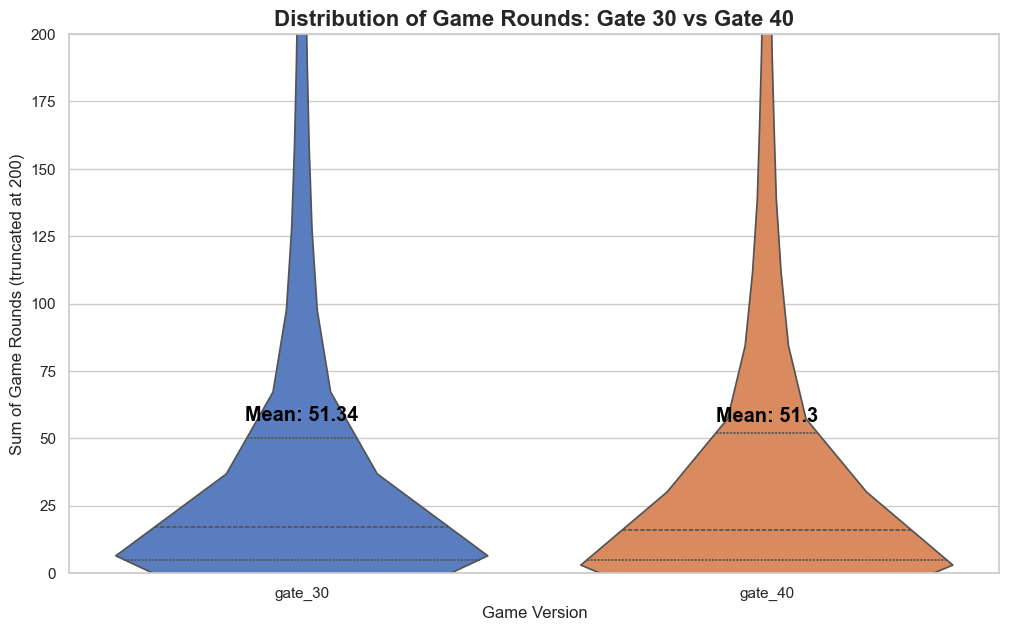

In [13]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 7))

ax = sns.violinplot(
    x='version', 
    y='sum_gamerounds', 
    data=df, 
    hue='version', 
    inner="quartile", 
    palette="muted", 
    legend=False
)

plt.ylim(0, 200) 

means = df.groupby('version')['sum_gamerounds'].mean().round(2)
for i, v in enumerate(means):
    ax.text(
        i, 
        v + 5, 
        f'Mean: {v}', 
        horizontalalignment='center',
        size='large', 
        color='black', 
        weight='semibold'
    )

plt.title('Distribution of Game Rounds: Gate 30 vs Gate 40', fontsize=16, fontweight='bold')
plt.xlabel('Game Version', fontsize=12)
plt.ylabel('Sum of Game Rounds (truncated at 200)', fontsize=12)

plt.savefig('rounds_distribution.png', dpi=300)
plt.show()

In [15]:
boot_7d = []
for i in range(10000):
    boot_mean = df.sample(frac=1, replace=True).groupby('version')['retention_7'].mean()
    boot_7d.append(boot_mean)

boot_7d = pd.DataFrame(boot_7d)

boot_7d['diff'] = (boot_7d['gate_30'] - boot_7d['gate_40']) / boot_7d['gate_40'] * 100

## 2. Statistical Analysis & Bootstrapping
Since retention is a binary variable (Bernoulli trial), we use **Bootstrapping** to:
1. Generate 10,000 resamples of our dataset.
2. Calculate the mean retention for each group in every sample.
3. Determine the distribution of the difference between groups.

This approach provides a more robust estimate of the probability that one version is truly better than the other.

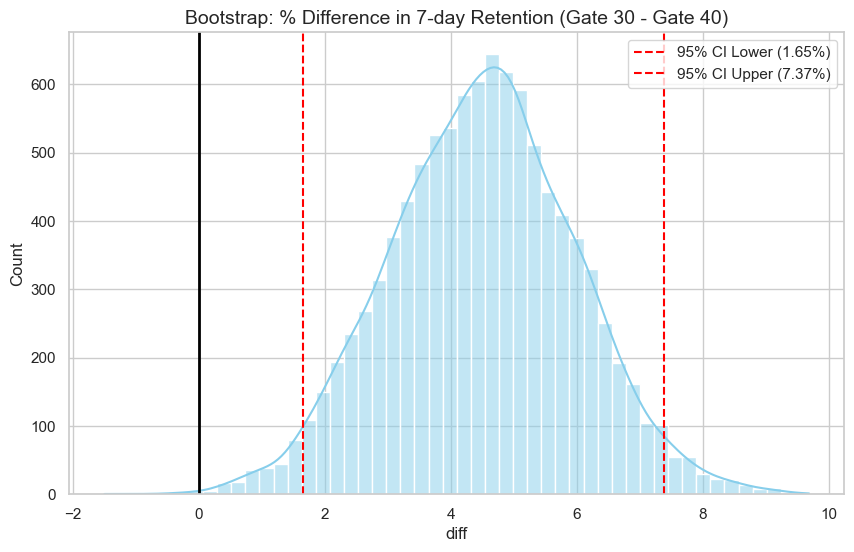

In [18]:
plt.figure(figsize=(10, 6))

sns.histplot(boot_7d['diff'], kde=True, color="skyblue", bins=50)

ci_low, ci_high = boot_7d['diff'].quantile([0.025, 0.975])
plt.axvline(ci_low, color='red', linestyle='--', label=f'95% CI Lower ({ci_low:.2f}%)')
plt.axvline(ci_high, color='red', linestyle='--', label=f'95% CI Upper ({ci_high:.2f}%)')
plt.axvline(0, color='black', lw=2)

plt.title('Bootstrap: % Difference in 7-day Retention (Gate 30 - Gate 40)', fontsize=14)
plt.legend()
plt.show()

# Final Conclusion & Business Recommendations

## 1. Statistical Summary
After running a **Bootstrap analysis** with 10,000 iterations, we observed the following results for **7-day Retention**:
* **Probability of Superiority:** There is a **98.2% probability** that the `gate_30` version has higher retention than `gate_40`.
* **Confidence Interval:** The 95% CI for the difference in retention does not cross 0, confirming that the result is **statistically significant**.

## 2. Product Insights & KPI Impact
As a **Product Analyst**, I evaluated the following:
* **Player Burnout:** Delaying the first gate to level 40 increases the risk of player exhaustion. The "forced break" at level 30 acts as a psychological reset, improving long-term habit formation.
* **LTV Implications:** A drop in Day-7 retention directly negatively impacts the **Customer Lifecycle** and estimated **LTV**.

## 3. Executive Decision
> **Recommendation:** **REJECT THE CHANGE**

**Action Plan:**
1. Keep the first gate at **Level 30**.
2. Do not roll out the `gate_40` version to the full user base, as it will lead to a significant decrease in weekly active users.
3. Further experiments could focus on the *type* of gate (e.g., social vs. timer) rather than just the level placement.
